### Simulating an electrode cluster for a single participant 
- Simulating a small cluster of electrodes for a single participant
- Calculate power spectra for each participant electrode cluster and then average the power spectra together
- Plot the Spectral Model for the average power spectra of the 10 participants
- Logic can be applied to electrode clusters of various sizes in various locations based on correlations between the specified electrode and Cz and the number of participants increased

### Imports

In [1]:
# Imports required for functionality 
import numpy as np
from matplotlib import pyplot 
import matplotlib.pyplot as plt

from neurodsp.utils import create_times
from neurodsp.sim import sim_oscillation, set_random_seed, sim_combined
from neurodsp.plts import plot_time_series, plot_power_spectra
from neurodsp.spectral import compute_spectrum_welch

from simulate_cz_signal import generate_cz_signal

from specparam import SpectralGroupModel
from specparam.plts import plot_spectra
from specparam.sim import sim_group_power_spectra

#### Simulating EEG-like signal for a cluster of 3 electrodes for multiple ppts

In [2]:
# Define n_ppts, correlations between Cz and specified electrodes
n_ppts = 10
corr_factors = {
    'F1': 0.6,
    'F3': 0.6,
    'F5': 0.4
}

electrodes = ['F1', 'F3', 'F5']

group_powers = {elect: [] for elect in electrodes}

In [10]:
cluster_psds = []
for p in range(n_ppts):
    
    # Generate signals
    cz_signal = generate_cz_signal(seed=256 + p, n_seconds=10, s_rate=250)
    electrode_signals = {}

    for ele, rho in corr_factors.items():
        sigma_source = np.std(cz_signal)
        noise_std = np.sqrt((1 - rho**2) / rho**2) * sigma_source
        noise = noise_std * np.random.randn(len(cz_signal))
        electrode_signals[ele] = rho * cz_signal + noise

    #Compute PSD for each electrode
    psds = []

    for ele in electrodes:
        sig = electrode_signals[ele]
        freqs, powers = compute_spectrum_welch(sig, fs=250)
        psds.append(powers)
        
     # Average electrodes → ONE cluster PSD per participant
    cluster_powers = np.mean(psds, axis=0)

    # Store it
    cluster_psds.append(cluster_powers)

all_powers= np.array(cluster_psds)

C:\Users\chloe\OneDrive\Documents\Anaconda\envs\diss_worksheet\Lib\site-packages\specparam\data\data.py:292: RuntimeWarning: specparam fit warning - skipping frequency == 0, as this causes a problem with fitting.
  warn(msg, category=RuntimeWarning)



	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.

Fitting model across 10 power spectra.
                                                                                                  
                            GROUP SPECTRAL MODEL RESULTS (10 spectra)                             
                                                                                                  
                       The model was fit with the 'spectral_fit' algorithm                        
              Model was fit to the 1-125 Hz frequency range with 1.00 Hz resolution               
                                                                                                  
                               Aperiodic Parameters ('fixed' mode)                                
          

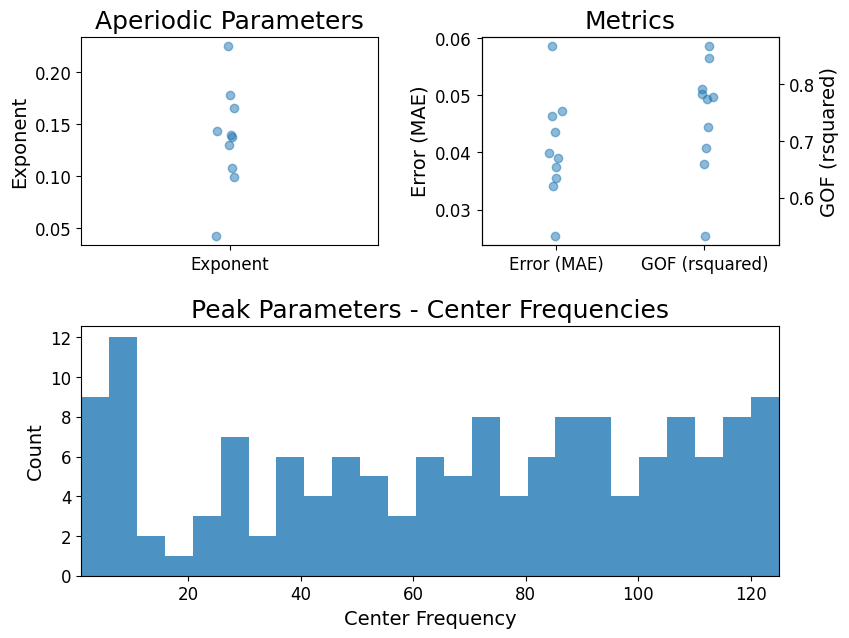

In [11]:
fg = SpectralGroupModel() 
fg.fit(freqs, all_powers) 
fg.print_results() 
fg.plot()